In [6]:
import numpy as np
import pandas as pd
from scipy.special import expit

In [19]:
import matplotlib.pyplot as plt
import networkx as nx


def draw_dag():
    G = nx.DiGraph()

    # Main DAG edges
    edges = [
        ("Z1", "A"),
        ("Z2", "panss5"),

        ("A", "panss5"),
        ("panss5", "psp6"),
        ("psp6", "Y"),

        ("L", "A"),
        ("L", "panss5"),
        ("L", "psp6"),

        ("U", "A"),
        ("U", "panss5"),
        ("U", "psp6"),
    ]

    # Curved direct treatment effect edges
    curved_edges = [
        ("A", "psp6"),
    ]

    G.add_edges_from(edges + curved_edges)

    pos = {
        "Z1": (0.0, 1.6),
        "Z2": (0.0, 0.2),

        "L": (2.0, 2.8),
        "A": (2.0, 1.6),

        "U": (4.0, 2.8),
        "panss5": (4.0, 1.6),

        "psp6": (6.0, 1.6),
        "Y": (8.0, 1.6),
    }

    colors = {
        "Z1": "lightskyblue",   # IV for treatment
        "Z2": "lightskyblue",   # IV for mediator
        "U": "lightcoral",      # unmeasured confounder
        "L": "khaki",           # measured confounder
        "A": "lightgreen",
        "panss5": "lightgreen",
        "psp6": "lightgreen",
        "Y": "lightgreen",
    }

    node_colors = [colors.get(n, "lightgreen") for n in G.nodes()]

    plt.figure(figsize=(12, 5))

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=2400,
        edgecolors="black",
        linewidths=1.0
    )

    # Draw labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=11,
        font_weight="bold"
    )

    # Draw regular edges
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        arrows=True,
        arrowsize=22,
        width=1.6,
        node_size=2400,
        connectionstyle="arc3,rad=0.0"
    )

    # Draw curved edges
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=curved_edges,
        arrows=True,
        arrowsize=22,
        width=1.8,
        node_size=2400,
        connectionstyle="arc3,rad=0.25"
    )

    plt.title(
        "DAG: IVs, continuous PANSS mediator, PSP outcome, measured and unmeasured confounding",
        fontsize=13
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [21]:
import numpy as np
import pandas as pd
from scipy.special import expit


def simulate_panss_based_data(N=5000, with_u=True, seed=42):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Z1: Instrument for treatment assignment.
    # Clinical interpretation:
    # Z1 represents physician or medical center prescribing preference
    # for Paliperidone.
    #
    # IV assumptions:
    # 1. Z1 affects A, the probability of receiving Paliperidone.
    # 2. Z1 does not directly affect the mediator or the outcome,
    #    except through treatment A.
    # 3. Z1 is independent of the unmeasured confounder U.
    # --------------------------------------------------
    Z1 = rng.binomial(1, 0.5, N)

    # --------------------------------------------------
    # Z2: Instrument for the measured PANSS mediator.
    # Clinical interpretation:
    # Z2 represents PANSS rater calibration or site-level PANSS scoring tendency.
    # In a multi-center study, some raters/sites may systematically score PANSS
    # slightly lower or identify symptom improvement more readily.
    #
    # IV assumptions:
    # 1. Z2 affects the measured PANSS score at week 5.
    # 2. Z2 does not directly affect PSP improvement Y.
    # 3. Z2 is independent of the unmeasured confounder U.
    # 4. Z2 is not related to treatment assignment A.
    #
    # Important:
    # Z2 is not a treatment-related variable.
    # It affects only the measured mediator panss5.
    # --------------------------------------------------
    Z2 = rng.binomial(1, 0.5, N)

    # --------------------------------------------------
    # Baseline variables based on the PANSS paper
    # --------------------------------------------------
    age = np.clip(rng.normal(37, 11, N), 18, 65)
    male = rng.binomial(1, 0.65, N)
    bmi0 = np.clip(rng.normal(26, 6, N), 15, 42)
    panss0 = np.clip(rng.normal(47, 7.5, N), 31, 76)
    psp0 = np.clip(rng.normal(49, 15, N), 20, 90)
    sas0 = np.clip(rng.normal(3, 5, N), 0, 35)

    # --------------------------------------------------
    # L: Measured baseline severity.
    # Higher L means worse measured baseline condition:
    # - Higher baseline PANSS increases L.
    # - Lower baseline PSP increases L.
    # - Higher BMI and SAS slightly increase L.
    #
    # L is observed by the researcher and can be adjusted for.
    # --------------------------------------------------
    L = (
        0.50 * ((panss0 - 47) / 7.5)
        - 0.40 * ((psp0 - 49) / 15)
        + 0.15 * ((bmi0 - 26) / 6)
        + 0.15 * ((sas0 - 3) / 5)
    )

    # --------------------------------------------------
    # U: Unmeasured confounder.
    # Clinical interpretation:
    # U represents latent disease severity, cognition,
    # adherence, family support, or other unmeasured factors.
    #
    # U affects:
    # - A: probability of receiving treatment.
    # - panss5: symptom severity at week 5.
    # - psp6 / Y: social functioning improvement.
    #
    # U is generated in the simulation, but in the actual analysis
    # it should be treated as unobserved.
    # --------------------------------------------------
    U = rng.normal(0, 1, N)

    # --------------------------------------------------
    # Control whether unmeasured confounding exists.
    # with_u=True creates unmeasured confounding.
    # with_u=False removes the effect of U.
    # --------------------------------------------------
    if not with_u:
        U_effect_A = 0.0
        U_effect_PANSS = 0.0
        U_effect_PSP = 0.0
        U_effect_WG = 0.0
        U_effect_SAS = 0.0
    else:
        U_effect_A = 0.8
        U_effect_PANSS = 3.0
        U_effect_PSP = -3.0
        U_effect_WG = 0.01
        U_effect_SAS = 0.5

    # --------------------------------------------------
    # A: Treatment assignment.
    # A = 1 means the patient receives Paliperidone.
    # A = 0 means the patient receives placebo / no Paliperidone.
    #
    # In the original PANSS paper, treatment was randomized.
    # In this simulation, treatment assignment is observational:
    # A depends on Z1, measured severity L, and unmeasured confounding U.
    #
    # Notice:
    # Z2 is not included here, because Z2 should not affect treatment assignment.
    # --------------------------------------------------
    p_A = expit(
        -0.30
        + 1.20 * Z1
        + 0.60 * L
        + U_effect_A * U
    )
    A = rng.binomial(1, p_A)

    # --------------------------------------------------
    # panss5: PANSS score at week 5.
    # This is the main continuous mediator.
    #
    # In this simulation:
    # - A lowers PANSS, representing treatment benefit.
    # - Z2 lowers measured PANSS, representing rater/site scoring tendency.
    # - L and U increase PANSS, representing worse measured and unmeasured severity.
    #
    # Notice:
    # Z2 is included here directly, not as A*Z2,
    # because it is not a treatment-response variable.
    # It is a PANSS measurement/scoring tendency.
    # --------------------------------------------------
    panss5 = (
        37.5
        - 4.0 * A
        - 2.0 * Z2
        + 4.0 * L
        + U_effect_PANSS * U
        + rng.normal(0, 8.5, N)
    )
    panss5 = np.clip(panss5, 7, 90)

    # --------------------------------------------------
    # wg: Percent weight gain after treatment.
    # WG appears in the PANSS paper as a possible adverse-event variable.
    #
    # In the main project simulation, WG is not the central mediator.
    # We keep it to preserve part of the clinical story of the PANSS paper.
    # --------------------------------------------------
    wg = (
        -0.01
        + 0.03 * A
        + 0.01 * L
        + U_effect_WG * U
        + rng.normal(0, 0.045, N)
    )
    wg = np.clip(wg, -0.10, 0.40)

    # --------------------------------------------------
    # sas_max: Maximum SAS score after baseline.
    # SAS represents extrapyramidal / motor adverse events.
    #
    # In the PANSS paper, SAS was examined as a possible mediator,
    # but it was not statistically significant in the final mediation analysis.
    # Therefore, we keep SAS as a secondary clinical variable.
    # --------------------------------------------------
    sas_max = (
        2.8
        + 0.7 * A
        + 0.8 * L
        + U_effect_SAS * U
        + rng.normal(0, 5.5, N)
    )
    sas_max = np.clip(sas_max, 0, 35)

    # --------------------------------------------------
    # psp6: PSP score at week 6.
    # PSP measures personal and social functioning.
    # Higher PSP means better social functioning.
    #
    # Main mediation pathway:
    # A affects continuous PANSS at week 5,
    # and PANSS affects PSP at week 6.
    #
    # In this simulation:
    # - A has a direct effect on PSP.
    # - panss5 affects PSP as the main clinical mediator.
    # - WG and SAS are included as secondary clinical factors.
    # - L and U affect PSP, creating measured and unmeasured confounding.
    #
    # Notice:
    # Z2 is not included directly here.
    # This enforces the exclusion restriction:
    # Z2 affects PSP only through PANSS, not directly.
    # --------------------------------------------------
    psp6 = (
        psp0
        + 5.0 * A
        - 0.85 * (panss5 - 37.5)
        + 35.0 * wg
        - 120.0 * (wg ** 2)
        - 0.10 * sas_max
        - 1.0 * L
        + U_effect_PSP * U
        + rng.normal(0, 10, N)
    )
    psp6 = np.clip(psp6, 1, 100)

    # --------------------------------------------------
    # Y: Binary outcome.
    # Y = 1 means clinically meaningful improvement in social functioning.
    # Y = 0 means no clinically meaningful improvement.
    #
    # We define improvement as an increase of at least 10 PSP points
    # from baseline to week 6.
    #
    # This binary outcome is needed because NNT, NNE, and EIN
    # are based on event probabilities.
    # --------------------------------------------------
    Y = ((psp6 - psp0) >= 10).astype(int)

    # --------------------------------------------------
    # Return the simulated dataset.
    #
    # Important:
    # U is returned only for simulation validation and for computing
    # the true effects. In the actual estimation step, U should be
    # removed or ignored to mimic a real observational study with
    # unmeasured confounding.
    # --------------------------------------------------
    df = pd.DataFrame({
        "Z1": Z1,
        "Z2": Z2,
        "L": L,
        "U": U,
        "A": A,
        "Y": Y,
        "age": age,
        "male": male,
        "bmi0": bmi0,
        "panss0": panss0,
        "panss5": panss5,
        "psp0": psp0,
        "psp6": psp6,
        "wg": wg,
        "sas0": sas0,
        "sas_max": sas_max,
        "p_A": p_A,
    })

    return df

In [23]:
df = simulate_panss_based_data(N=10000, with_u=True, seed=42)

print(df[["A", "Y", "Z1", "Z2"]].mean())

print(
    df.groupby("A")[["panss0", "panss5", "psp0", "psp6", "Y"]].mean()
)

print(
    df.groupby("Z1")[["A", "Y"]].mean()
)

print(
    df.groupby("Z2")[["A", "panss5", "Y"]].mean()
)

A     0.5652
Y     0.3671
Z1    0.4985
Z2    0.5077
dtype: float64
      panss0     panss5       psp0       psp6         Y
A                                                      
0  46.148233  34.846600  50.855568  53.101669  0.290478
1  47.654498  33.709467  47.976551  55.341643  0.426044
           A         Y
Z1                    
0   0.439880  0.331805
1   0.691274  0.402608
           A     panss5         Y
Z2                               
0   0.574040  35.226784  0.347146
1   0.556628  33.212028  0.386449


The sanity checks suggest that the simulated data behave according to the intended clinical and causal structure. Overall, approximately 56.5% of patients receive treatment, while 36.7% achieve a clinically meaningful PSP improvement. The two instruments, "Z1" and "Z2", are approximately balanced, with probabilities close to 0.5.

Patients who receive treatment, "A=1", start with slightly worse baseline status: they have higher baseline PANSS and lower baseline PSP compared with untreated patients. This reflects the intended observational treatment assignment with confounding by disease severity. Despite this worse baseline condition, treated patients have lower PANSS at week 5, higher PSP at week 6, and a higher probability of PSP improvement, "Y=0.426", compared with "Y=0.290" among untreated patients.

The instrument "Z1" behaves as intended: it strongly affects treatment assignment, increasing the probability of treatment from about 0.44 to 0.69. The instrument "Z2" behaves as an instrument for the PANSS mediator: it has little effect on treatment assignment, but it lowers the measured PANSS score at week 5 and is associated with a higher probability of PSP improvement. This is consistent with the assumed pathway "Z2 -> panss5 -> psp6 -> Y", without a direct effect of "Z2" on treatment.

In [24]:
df = simulate_panss_based_data(N=10000, with_u=True, seed=42)

panss_response = ((df["panss0"] - df["panss5"]) >= 10).astype(int)

print(df[["A", "Y", "Z1", "Z2"]].mean())
print("PANSS response rate:", panss_response.mean())

print(
    df.assign(panss_response=panss_response)
      .groupby("A")[["panss0", "panss5", "psp0", "psp6", "panss_response", "Y"]]
      .mean()
)

print(
    df.assign(panss_response=panss_response)
      .groupby("Z1")[["A", "panss_response", "Y"]]
      .mean()
)

print(
    df.assign(panss_response=panss_response)
      .groupby("Z2")[["A", "panss5", "panss_response", "Y"]]
      .mean()
)

A     0.5652
Y     0.3671
Z1    0.4985
Z2    0.5077
dtype: float64
PANSS response rate: 0.6042
      panss0     panss5       psp0       psp6  panss_response         Y
A                                                                      
0  46.148233  34.846600  50.855568  53.101669        0.551288  0.290478
1  47.654498  33.709467  47.976551  55.341643        0.644904  0.426044
           A  panss_response         Y
Z1                                    
0   0.439880        0.590828  0.331805
1   0.691274        0.617653  0.402608
           A     panss5  panss_response         Y
Z2                                               
0   0.574040  35.226784        0.569978  0.347146
1   0.556628  33.212028        0.637384  0.386449


The additional sanity checks include a temporary "panss_response" indicator, defined as a PANSS improvement of at least 10 points from baseline to week 5. This variable is not part of the final DGM and is not used in the causal effect calculations, but it is useful for checking whether the simulated PANSS process behaves as expected.

Overall, the PANSS response rate is about 60.4%. Treated patients, "A=1", have a higher PANSS response rate than untreated patients, 0.645 compared with 0.551, and also have a higher probability of clinically meaningful PSP improvement, "Y=0.426" compared with "Y=0.290". This supports the intended clinical pattern in which treatment improves PANSS symptoms and is associated with better PSP outcomes.

The instrument "Z1" strongly affects treatment assignment, increasing the probability of treatment from about 0.44 to 0.69. It is also associated with higher "panss_response" and higher "Y", mainly through its effect on treatment. The instrument "Z2" has little effect on treatment assignment, but it lowers "panss5", increases the PANSS response rate from 0.570 to 0.637, and is associated with a higher probability of PSP improvement. This supports the intended role of "Z2" as an instrument for the measured PANSS mediator.


### Assumptions and Structure of the Data-Generating Mechanism

In this simulation, we define a data-generating mechanism (DGM) that is based on the clinical story of the PANSS paper, but adapted to the research question of this project: estimating direct and indirect NNT, NNE, and EIN in observational studies with unmeasured confounding, instrumental variables, and G-estimation. The treatment variable "A" represents receiving Paliperidone versus placebo. Unlike the original study, in which treatment was randomized, treatment assignment in this simulation is observational. Specifically, "A" depends on measured baseline severity "L", an unmeasured confounder "U", and the instrumental variable "Z1". Therefore, the simulation intentionally includes confounding between treatment and outcome.

The main clinical mediator in the simulation is "panss5", the PANSS score at week 5. This variable represents psychiatric symptom severity after treatment initiation. It is affected by treatment "A", measured baseline severity "L", the unmeasured confounder "U", and the instrumental variable "Z2". The variable "Z2" represents PANSS rater calibration or site-level PANSS scoring tendency. Therefore, it affects the measured PANSS score, but is assumed not to directly affect treatment assignment or the final outcome. In the DGM, no separate binary mediator is included. Instead, the mediation pathway is defined through the continuous PANSS score at week 5, "panss5".

The continuous outcome in the simulation is "psp6", the PSP score at week 6, representing personal and social functioning. The outcome "psp6" is affected directly by treatment "A", by the continuous mediator "panss5", by measured baseline severity "L", by the unmeasured confounder "U", and by secondary clinical variables such as weight gain "wg" and extrapyramidal symptoms "sas_max". The binary outcome "Y", which is used for calculating NNT, NNE, and EIN, is defined as an improvement of at least 10 points in PSP from baseline to week 6. Thus, "Y=1" represents a clinically meaningful improvement in personal and social functioning.

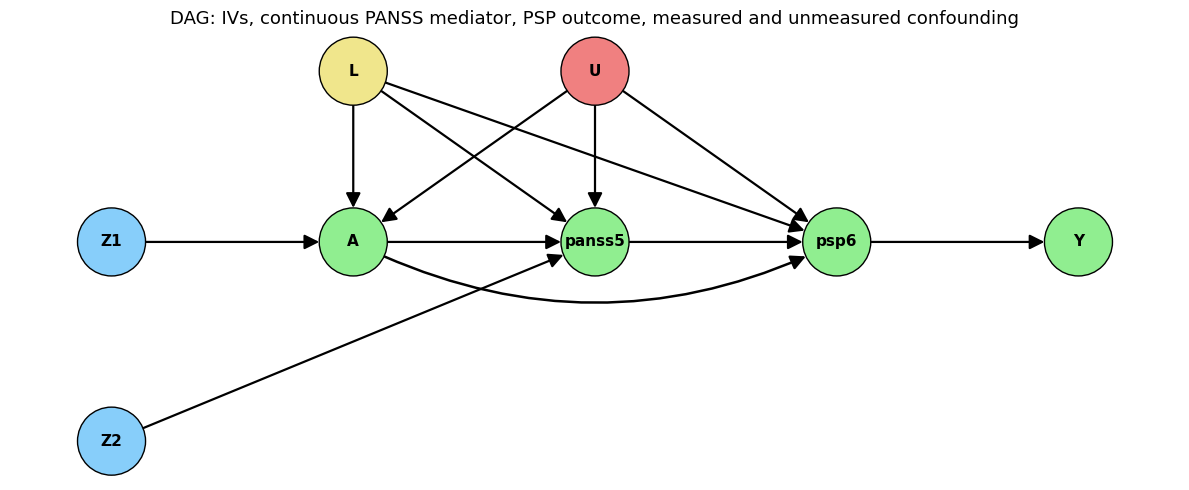

In [20]:
draw_dag()

Thus, "Z1" serves as an instrument for treatment assignment, "Z2" serves as an instrument for the measured PANSS mediator, "L" represents measured baseline severity, and "U" represents unmeasured disease severity or other unmeasured factors such as adherence, cognition, or family support. The key instrumental variable assumptions are that "Z1" affects the outcome only through treatment, and that "Z2" affects the outcome only through the measured PANSS mediator. In addition, both instruments are assumed to be independent of the unmeasured confounder "U".

The causal mediation pathway is represented by the continuous mediator "panss5", while "Y" remains the final binary outcome used for NNT, NNE, and EIN calculations.